# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [12]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [35]:
# loading cleaned data
df2 = pd.read_csv("AviationData_Cleaned_Final.csv", low_memory=False)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [55]:
df2['Event.Date'] = pd.to_datetime(df2['Event.Date'], errors='coerce')
df2['Year'] = df2['Event.Date'].dt.year

# Total passengers
df2["Total_Passengers"] = (
    df2["Total.Fatal.Injuries"].fillna(0) +
    df2["Total.Serious.Injuries"].fillna(0) +
    df2["Total.Uninjured"].fillna(0)
)

# Injury fraction
df2["Injury_Fraction"] = (
    (df2["Total.Fatal.Injuries"].fillna(0) +
     df2["Total.Serious.Injuries"].fillna(0))
    / df2["Total_Passengers"].replace(0, np.nan)
)

#threshold = 20

#df_small = df2[df2["Total_Passengers"] < threshold].copy()
#df_large = df2[df2["Total_Passengers"] >= threshold].copy()
THRESHOLD = 20

small = df2[df2['Estimated.Passengers'] <  THRESHOLD].copy()
large = df2[df2['Estimated.Passengers'] >= THRESHOLD].copy()

print(f"Small plane (< {THRESHOLD} pax): {len(small):,}")
print(f"Large plane (≥ {THRESHOLD} pax): {len(large):,}")

Small plane (< 20 pax): 84,720
Large plane (≥ 20 pax): 2,796


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

SMALL PLANE — Top 15 Makes (Lowest Harm Rate)
                       Make   n  mean_harm_rate  destroyed_rate
                       Snow  33        0.090909        0.121212
                       Waco 143        0.099068        0.083916
     Evektor-Aerotechnik As  30        0.100000        0.000000
          Grumman-Schweizer 127        0.111549        0.251969
                     Boeing 718        0.145422        0.104457
                      Helio 113        0.148364        0.115044
                      Maule 588        0.155130        0.098639
         Eagle Aircraft Co.  42        0.158730        0.309524
                        Let 136        0.161765        0.080882
         Aviat Aircraft Inc  77        0.162338        0.038961
         Brantly Helicopter  39        0.166667        0.205128
Diamond Aircraft Industries  44        0.175000        0.136364
            Boeing Stearman  51        0.176471        0.098039
                  Weatherly  94        0.180851        0.2

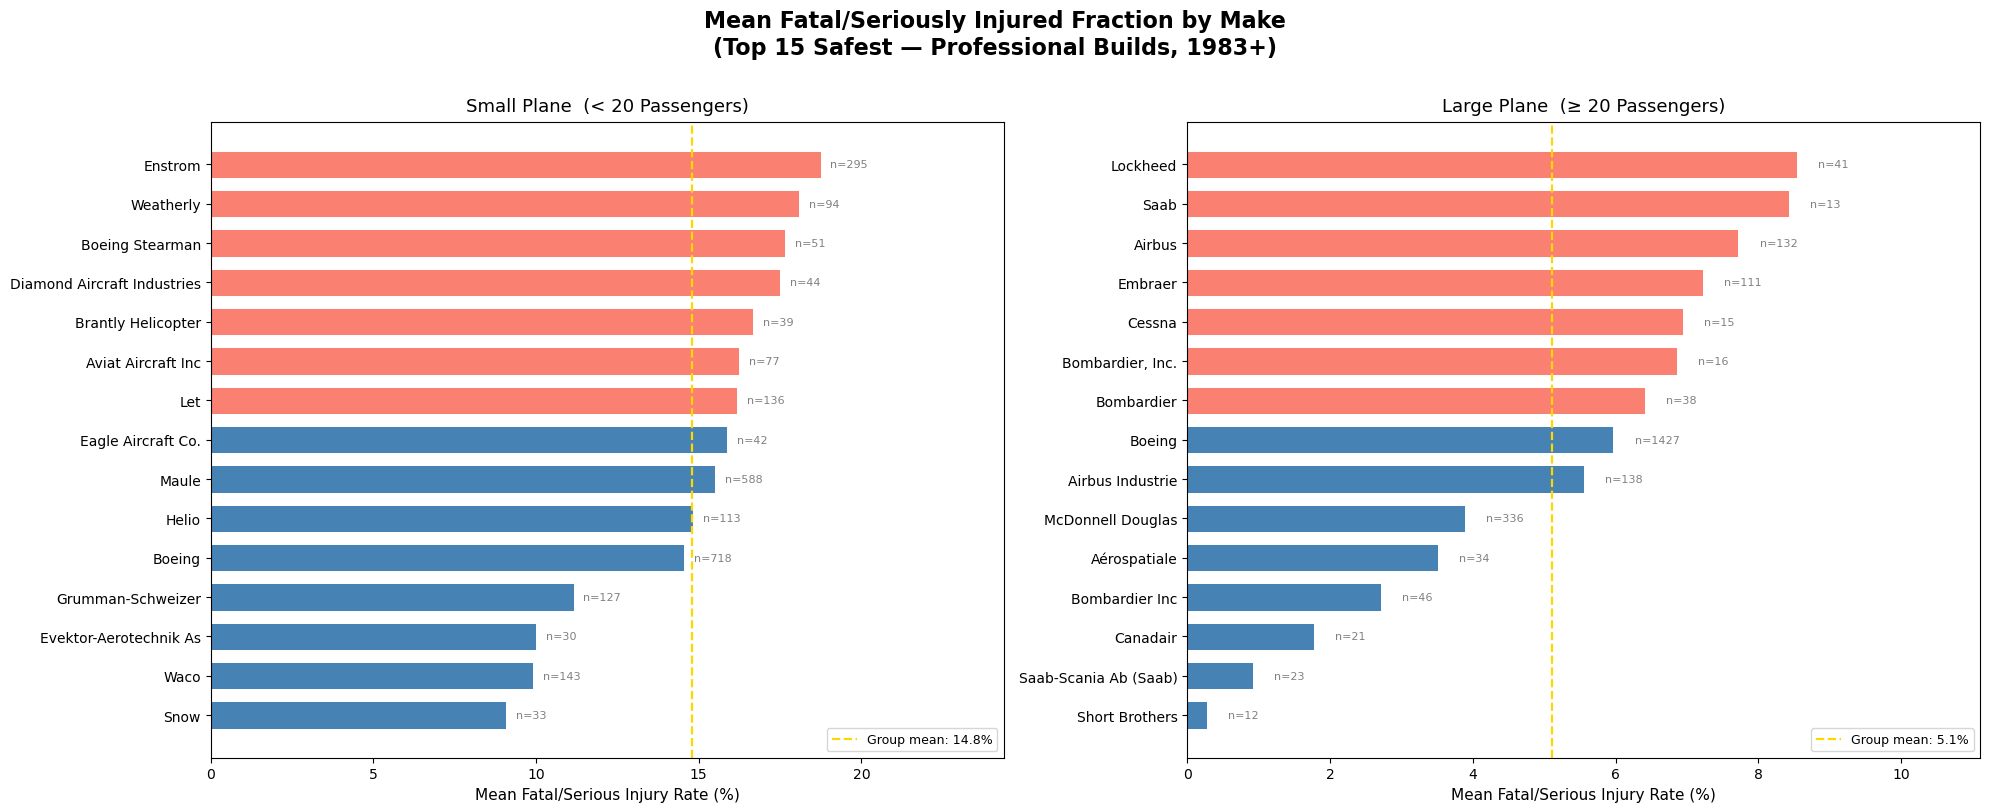

In [56]:
def make_stats(subset, min_n=30):
    stats_df = (
        subset
        .groupby('Make_clean')
        .agg(
            n                = ('Fatal.Serious.Rate', 'count'),
            mean_harm_rate   = ('Fatal.Serious.Rate', 'mean'),
            median_harm_rate = ('Fatal.Serious.Rate', 'median'),
            std_harm_rate    = ('Fatal.Serious.Rate', 'std'),
            destroyed_rate   = ('Aircraft.Destroyed', 'mean'),
        )
        .reset_index()
        .rename(columns={'Make_clean': 'Make'})
    )
    return stats_df[stats_df['n'] >= min_n].copy()

# Stats relax min_n to 10 for large (fewer commercial accidents) 
small_make = make_stats(small, min_n=30)
large_make = make_stats(large, min_n=10)

# Select top 15 safest makes for each group 
small_make_top15 = small_make.sort_values('mean_harm_rate').head(15)
large_make_top15 = large_make.sort_values('mean_harm_rate').head(15)

print("SMALL PLANE — Top 15 Makes (Lowest Harm Rate)")
print(small_make_top15[['Make', 'n', 'mean_harm_rate', 'destroyed_rate']].to_string(index=False))

print("\nLARGE PLANE — Top 15 Makes (Lowest Harm Rate)")
print(large_make_top15[['Make', 'n', 'mean_harm_rate', 'destroyed_rate']].to_string(index=False))

# Plot of the subgroups side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Mean Fatal/Seriously Injured Fraction by Make\n'
    '(Top 15 Safest — Professional Builds, 1983+)',
    fontsize=16, fontweight='bold', y=1.01
)

datasets = [
    (small_make_top15, axes[0], 'Small Plane  (< 20 Passengers)'),
    (large_make_top15, axes[1], 'Large Plane  (≥ 20 Passengers)'),
]

for df_m, ax, title in datasets:
    ordered    = df_m.sort_values('mean_harm_rate', ascending=True)
    median_val = ordered['mean_harm_rate'].median()
    colors     = ['steelblue' if v <= median_val else 'salmon'
                  for v in ordered['mean_harm_rate']]

    bars = ax.barh(
        ordered['Make'], ordered['mean_harm_rate'] * 100,
        color=colors, edgecolor='white', linewidth=0.7, height=0.7
    )
    ax.axvline(
        ordered['mean_harm_rate'].mean() * 100,
        color='gold', ls='--', lw=1.6,
        label=f"Group mean: {ordered['mean_harm_rate'].mean()*100:.1f}%"
    )
    for bar, (_, row) in zip(bars, ordered.iterrows()):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}",
            va='center', fontsize=8, color='grey'
        )

    ax.set_xlabel('Mean Fatal/Serious Injury Rate (%)', fontsize=11)
    ax.set_title(title, fontsize=13, pad=8)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, ordered['mean_harm_rate'].max() * 130)

plt.tight_layout()
plt.savefig('fig1_mean_harm_rate_by_make.png', dpi=150, bbox_inches='tight')
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


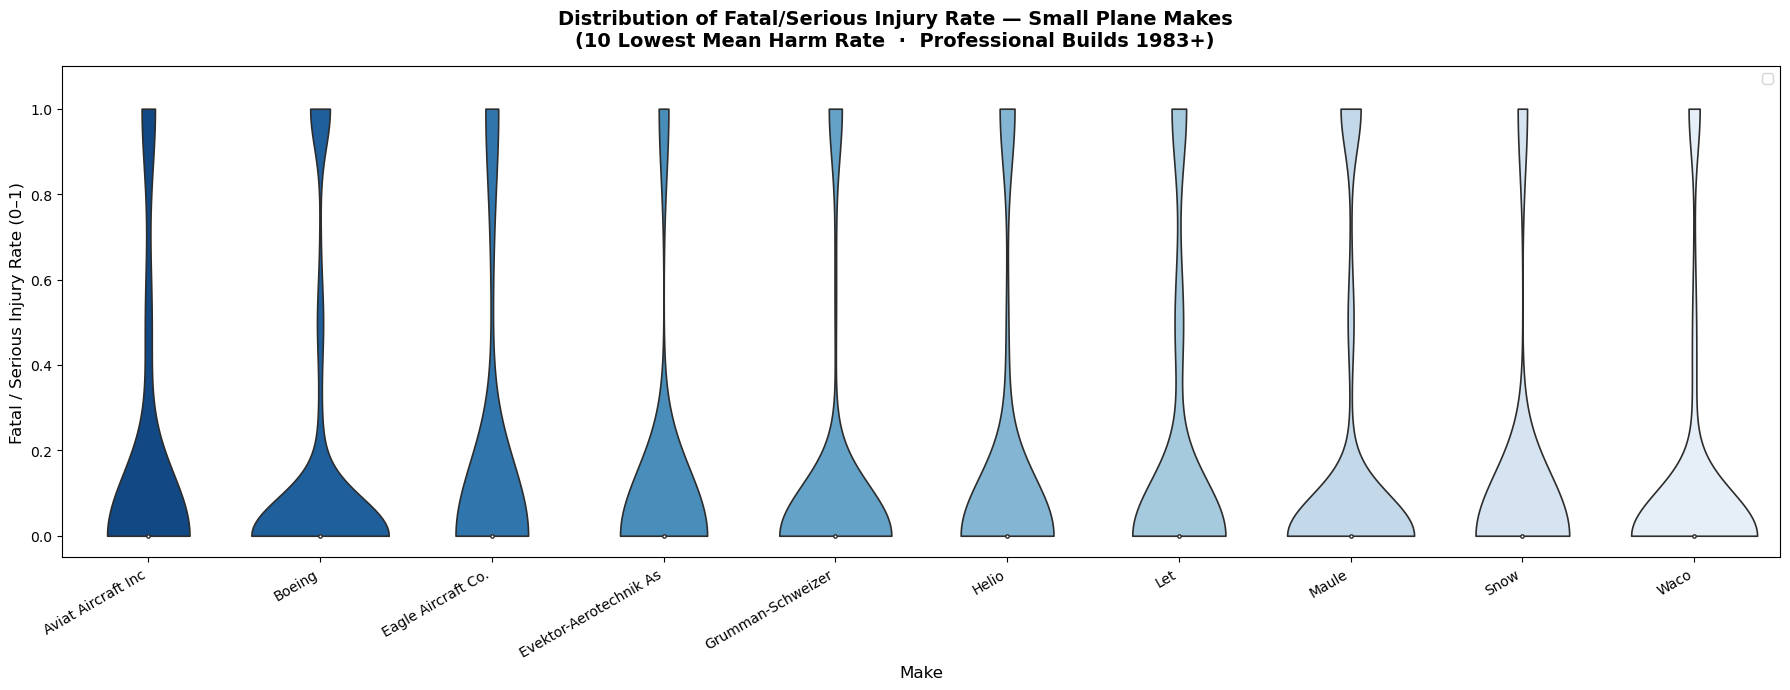

In [57]:

top10_small_makes = small_make.sort_values('mean_harm_rate').head(10)['Make'].tolist()
small_top10       = small[small['Make_clean'].isin(top10_small_makes)].copy()


order_small = (
    small_top10.groupby('Make_clean')['Fatal.Serious.Rate']
    .median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle(
    'Distribution of Fatal/Serious Injury Rate — Small Plane Makes\n'
    '(10 Lowest Mean Harm Rate  ·  Professional Builds 1983+)',
    fontsize=14, fontweight='bold'
)

sns.violinplot(
    data=small_top10, x='Make_clean', y='Fatal.Serious.Rate',
    order=order_small,
    palette=sns.color_palette('Blues_r', n_colors=len(order_small)),
    inner='box', cut=0, linewidth=1.2, ax=ax, saturation=0.85
)

ax.set_xlabel('Make', fontsize=12)
ax.set_ylabel('Fatal / Serious Injury Rate (0–1)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig2_violin_small_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\Georgina\AppData\Local\Temp\ipykernel_20892\3024525427.py:16: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
c:\Users\Georgina\anaconda3\conda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Georgina\anaconda3\conda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Georgina\AppData\Local\Temp\ipykernel_20892\3024525427.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


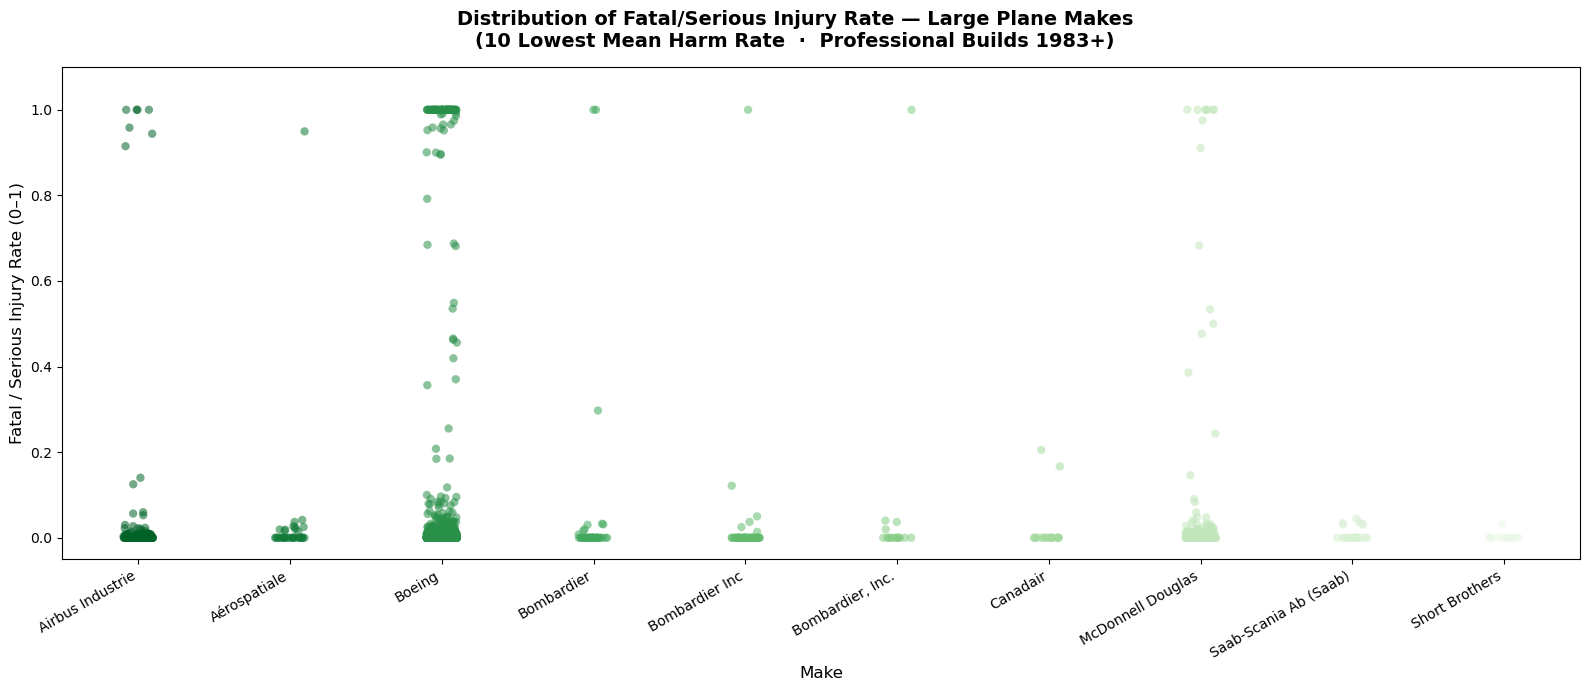

In [58]:
top10_large_makes = large_make.sort_values('mean_harm_rate').head(10)['Make'].tolist()
large_top10       = large[large['Make_clean'].isin(top10_large_makes)].copy()

order_large = (
    large_top10.groupby('Make_clean')['Fatal.Serious.Rate']
    .median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle(
    'Distribution of Fatal/Serious Injury Rate — Large Plane Makes\n'
    '(10 Lowest Mean Harm Rate  ·  Professional Builds 1983+)',
    fontsize=14, fontweight='bold'
)

sns.stripplot(
    data=large_top10, x='Make_clean', y='Fatal.Serious.Rate',
    order=order_large,
    palette=sns.color_palette('Greens_r', n_colors=len(order_large)),
    alpha=0.55, size=6, jitter=True, ax=ax
)


ax.set_xlabel('Make', fontsize=12)
ax.set_ylabel('Fatal / Serious Injury Rate (0–1)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.savefig('fig3_strip_large_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

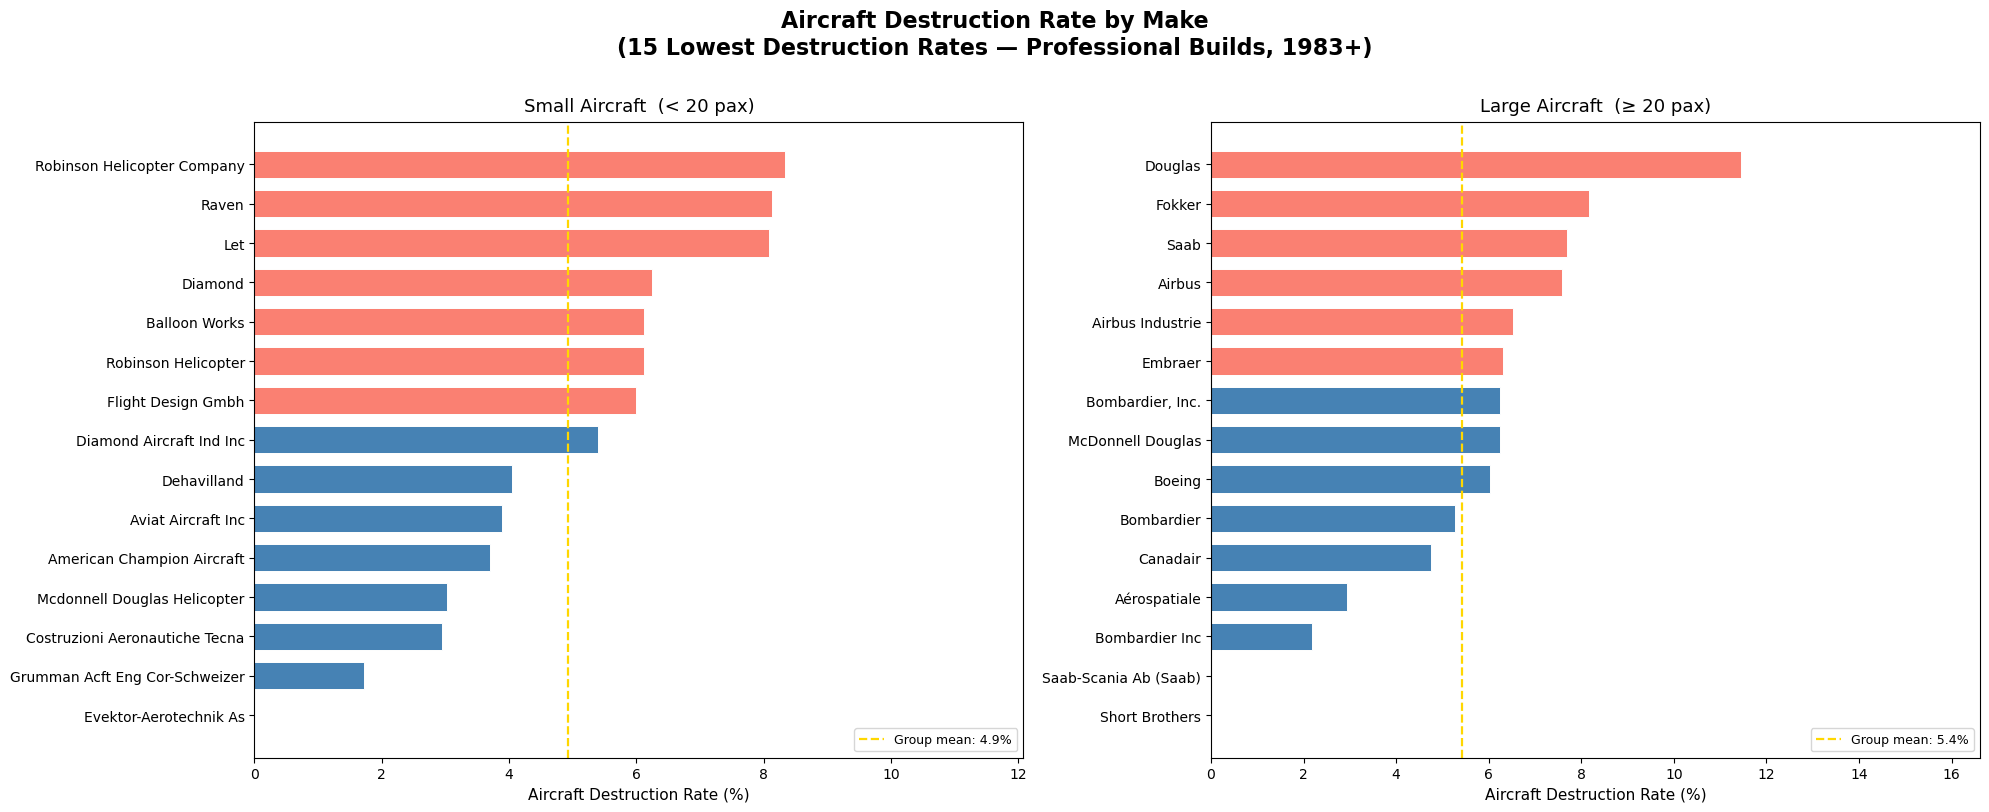

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Aircraft Destruction Rate by Make\n'
    '(15 Lowest Destruction Rates — Professional Builds, 1983+)',
    fontsize=16, fontweight='bold', y=1.01
)

for ax, df_m, title in [
    (axes[0], small_make.sort_values('destroyed_rate').head(15), 'Small Aircraft  (< 20 pax)'),
    (axes[1], large_make.sort_values('destroyed_rate').head(15), 'Large Aircraft  (≥ 20 pax)'),
]:
    ordered    = df_m.sort_values('destroyed_rate', ascending=True)
    median_val = ordered['destroyed_rate'].median()
    colors     = ['steelblue' if v <= median_val else 'salmon'
                  for v in ordered['destroyed_rate']]

    bars = ax.barh(
        ordered['Make'], ordered['destroyed_rate'] * 100,
        color=colors, edgecolor='white', linewidth=0.7, height=0.7
    )
    ax.axvline(
        ordered['destroyed_rate'].mean() * 100,
        color='gold', ls='--', lw=1.6,
        label=f"Group mean: {ordered['destroyed_rate'].mean()*100:.1f}%"
    )

    ax.set_xlabel('Aircraft Destruction Rate (%)', fontsize=11)
    ax.set_title(title, fontsize=13, pad=8)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim(0, ordered['destroyed_rate'].max() * 145)

plt.tight_layout()
plt.savefig('fig4_destruction_rate_by_make.png', dpi=150, bbox_inches='tight')
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [61]:
## Key Findings

### Makes (Small Aircraft)
#Several manufacturers consistently show low mean injury fractions.
#Distribution plots indicate variability within makes some have tight safety profiles, others show occasional high-risk events.

### Makes (Large Aircraft)
#Large aircraft generally exhibit lower variability in injury fractions.
#Stripplots show clustering near lower injury rates, suggesting more consistent safety outcomes.

### Aircraft Destruction
#Makes with low destruction rates often align with lower injury fractions.
#However, some makes show low injury rates but higher destruction → indicates survivability despite damage.

### Plane Types
#Filtering by ≥10 observations improves reliability.
#Smaller aircraft types show wider spread in injury outcomes.
#Larger aircraft types are more stable with lower variance.

## Recommendations

###Prefer makes that rank consistently low in BOTH:
#Injury fraction
#Destruction rate

###For small aircraft:
#Focus on makes with tight (low variance) distributions in violin plots.

###For large aircraft:
#Most are already stable; prioritize those with lowest mean injury fractions.

###Avoid makes/types with:
#High variability (unpredictable safety outcomes)
#High destruction despite low injury (hidden risk)

## Overall Insight
#Large aircraft are generally safer and more consistent.
#Small aircraft safety varies significantly by manufacturer and model.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.